# DM_G1_P0004_integrated_deep_answer

## 0. 정답본 범위

- Gate: G1
- Phase: P0004
- Topic: G1 통합 심화 — Simplex Tableau, Two-phase, Big-M, Duality Bridge
- Problem notebook: `DM_G1_P0004_integrated_deep.ipynb`
- Correct answers included: Yes
- Output language: Korean

이 정답본은 풀이 전에는 열지 않는 것을 권장한다.


## 1. 핵심 기준표

| 구분 | 판별 기준 |
| --- | --- |
| simplex tableau | objective row의 개선 가능 계수, RHS, ratio, basis를 함께 본다. |
| ratio test | entering column의 양수 계수 행만 후보로 본다. |
| 복수 최적해 | 최적 tableau에서 비기저변수 reduced cost가 0이면 대안 최적해 가능성이 있다. |
| 비유계 | 개선 가능한 entering variable은 있으나 ratio 후보가 없으면 unbounded 신호다. |
| two-phase | Phase I은 artificial 합을 0으로 만들 수 있는지 확인한다. |
| Big-M | artificial이 커질수록 objective가 나빠지도록 큰 벌점을 둔다. |
| duality | primal 제약은 dual 변수, primal 변수는 dual 제약에 대응한다. |
| complementary slackness | primal slack과 대응 dual variable의 곱은 0이어야 한다. |


## 2. 문항별 정답


### 심화문제 1 정답 — 스마트 물류센터 생산계획

#### 1. 표준형과 초기 tableau

표준형은 다음과 같다.

```text
z - 8x1 - 6x2 = 0
2x1 + x2 + s1 = 180
x1 + 2x2 + s2 = 160
x1 + s3 = 70
x2 + s4 = 60
x1, x2, s1, s2, s3, s4 >= 0
```

초기 기저변수는 `s1, s2, s3, s4`이고, 비기저변수는 `x1, x2`이다. 초기 BFS는 다음이다.

```text
(x1, x2, s1, s2, s3, s4) = (0, 0, 180, 160, 70, 60)
```

초기 tableau의 objective row는 `z - 8x1 - 6x2 = 0`이므로 `x1` 계수 `-8`, `x2` 계수 `-6`을 갖는다.

#### 2. 첫 entering/leaving/pivot

Dantzig rule에서는 가장 음수인 목적행 계수를 선택하므로 `x1`이 첫 entering variable이다. ratio test는 `x1` column의 양수 계수만 본다.

| 행 | 계수 | RHS | ratio |
| --- | ---: | ---: | ---: |
| `s1` | 2 | 180 | 90 |
| `s2` | 1 | 160 | 160 |
| `s3` | 1 | 70 | 70 |
| `s4` | 0 | 60 | 제외 |

최소 양수 ratio는 70이므로 leaving variable은 `s3`이고 pivot element는 `s3` 행, `x1` 열의 `1`이다. 첫 pivot 후 basis는 `s1, s2, x1, s4`이다. 새 BFS는 `x1=70, x2=0`을 기준으로 `s1=40`, `s2=90`, `s3=0`, `s4=60`이다.

그래프 관점에서 첫 pivot은 원점 `(0,0)`에서 `x1` 방향으로 이동해 `x1=70` 경계의 꼭짓점 `(70,0)`으로 가는 이동이다. 즉 pivot은 단순 행연산이 아니라 인접 BFS로 이동하는 절차다.

#### 3. 최적해와 복수 최적해 판정

원 목적함수 `z=8x1+6x2`의 최적점은 두 자원 제약의 교점이다.

```text
2x1 + x2 = 180
x1 + 2x2 = 160
=> x1 = 200/3, x2 = 140/3
```

최적 목적값은 `z* = 8(200/3)+6(140/3)=2440/3`이다.

목적함수를 `z=8x1+4x2=4(2x1+x2)`로 바꾸면 목적함수 등고선이 첫 번째 제약 `2x1+x2=180`과 평행하다. 이때 feasible region에서 `2x1+x2=180`을 만족하는 최적 face의 구간, 즉 `(70,40)`부터 `(200/3,140/3)`까지가 같은 목적값 `720`을 준다. 복수 최적해는 이 face 위의 점들만 최적이라는 뜻이지 아무 feasible point나 최적이라는 뜻이 아니다.

#### 4. 비유계 신호

“개선 가능한 entering variable은 있으나 해당 column의 모든 제약행 계수가 0 이하”이면 ratio test 후보가 없다. 이는 objective를 계속 개선해도 어떤 제약도 먼저 막지 않는다는 뜻이므로 `unbounded`이다. `infeasible`은 실행가능해가 없다는 뜻이므로 이 신호와 다르다.

#### 5. Solver mapping

- changing cells: `x1`, `x2`가 들어가는 셀
- target cell: `8x1+6x2`를 계산하는 총이익 셀
- constraint LHS cells: `2x1+x2`, `x1+2x2`, `x1`, `x2`
- RHS cells: `180`, `160`, `70`, `60`
- 옵션: `Max`, `Simplex LP`, `x1,x2>=0` nonnegativity

#### 6. 근거

- node_id: `n_DM_PDF01.simplex_tableau`, `n_DM_PDF01.entering_leaving_variable`, `n_DM_PDF01.minimum_ratio_test`, `n_DM_PDF01.pivot_operation`, `n_DM_PDF01.multiple_optima`, `n_DM_PDF01.unbounded_solution`
- source anchors: `DM_PDF01:p001:L003`, `DM_PDF01:p002:L003`, `DM_PDF01:p003:L003`

#### 7. 자주 하는 오답

- ratio test에서 `s4` 행처럼 계수 0인 행을 후보로 넣는다.
- reduced cost 0을 “그 변수는 의미 없다”로 해석한다.
- 복수 최적해를 feasible region 전체가 최적이라는 뜻으로 해석한다.
- unbounded를 infeasible과 같은 말로 쓴다.

<!-- ITEM_VISUAL_CARD:DM_G1_P0004_Q01:START -->
#### 문항별 시각 학습자료

![DM_G1_P0004_Q01](../visual_assets/item_cards/DM_G1_P0004_Q01.png)

- 노드-간선 경로: `simplex_tableau` -> `ratio_test` -> `multiple_optima` -> `unbounded`
- 보는 순서: 2차원 실행가능영역 또는 ratio 막대를 먼저 보고, 그 다음 basis 교체/종료 신호를 판정한다.
- 그래프 해석: 최적해 이론의 핵심 판정 신호가 그래프에서 어디에 나타나는지 본다.
- 오답 방지: 계산 결과만 보지 말고 어떤 노드에서 어떤 노드로 이동하는지 설명한다.
<!-- ITEM_VISUAL_CARD:DM_G1_P0004_Q01:END -->


### 심화문제 2 정답 — 응급 물류 혼합계획

#### 1. 보조변수 판정표

| 제약 | 유형 | 필요한 변수 | 표준형 |
| --- | --- | --- | --- |
| `x1+x2<=30` | 상한 제약 | slack `s1` | `x1+x2+s1=30` |
| `3x1+2x2>=48` | 하한 제약 | surplus `s2`, artificial `a2` | `3x1+2x2-s2+a2=48` |
| `x1+2x2=28` | 등식 제약 | artificial `a3` | `x1+2x2+a3=28` |

초기 basis 후보는 `s1, a2, a3`이다. 두 번째 제약에서 surplus만 도입하면 `3x1+2x2-s2=48`이 되는데, `-s2`는 단위열 `+1` basis를 만들지 못한다. 그래서 artificial variable `a2`가 필요하다. 세 번째 등식 제약은 slack이나 surplus로 단위열을 만들 수 없으므로 artificial variable `a3`가 필요하다.

#### 2. Phase I objective와 종료조건

Phase I objective는 artificial variables의 합을 최소화하는 것이다.

```text
min w = a2 + a3
```

`w*=0`은 artificial variables를 모두 0으로 만들 수 있다는 뜻이다. 즉 원문제 제약만으로 feasible basis가 존재한다는 뜻이다. 이것은 원문제의 최적 목적값 `z*`가 0이라는 뜻이 아니다. Phase I은 feasibility를 찾는 단계이고, Phase II에서 원래 목적함수 `z=7x1+5x2`를 다시 넣어 최적화한다.

#### 3. Phase II 전환 절차

Phase I 종료 후 artificial variables가 모두 비기저가 되었다면 다음 순서로 전환한다.

1. artificial variable 열을 tableau에서 제거한다.
2. Phase I objective `w`를 제거한다.
3. 원 목적함수 `z=7x1+5x2`를 objective row로 다시 넣는다.
4. Phase I에서 얻은 feasible basis를 Phase II의 초기 basis로 사용한다.
5. simplex pivot을 계속 수행해 원 목적함수를 최적화한다.

이 문제 자체의 feasible set을 직접 풀면 `x1+2x2=28`에서 `x1=28-2x2`이고, objective는 `z=7(28-2x2)+5x2=196-9x2`이다. 실행가능 범위에서 `x2=0`, `x1=28`이 최적 후보가 되며 `z=196`이다. 이 계산은 Phase II의 목적함수 최적화에 해당한다.

#### 4. 오답 진단

학생 답안 `3x1+2x2+s2+a2=48`의 오류는 `>=` 제약에서 surplus를 더한 것이다. 올바른 표준형은 다음이다.

```text
3x1 + 2x2 - s2 + a2 = 48
```

현실 언어로 보면 `3x1+2x2`가 최소 요구량 48을 초과할 수 있고, 그 초과량이 surplus이다. 따라서 `LHS = RHS + surplus`이고 이를 등식으로 쓰면 `LHS - surplus = RHS`가 된다. surplus를 뺀 뒤에도 초기 basis가 없으므로 artificial variable이 필요하다.

#### 5. artificial positive 판정

Phase I 최적해에서 `a3=2`가 양수로 남으면 원문제는 infeasible이다. artificial variable은 원문제에 없는 임시 변수이므로 최종적으로 0이어야 원문제와 동치다. 양수로 남는다는 것은 원래 제약만으로는 해당 등식을 만족하는 feasible basis가 없다는 뜻이다.

#### 6. Solver mapping

- changing cells: `x1`, `x2`
- target cell: `7x1+5x2` 효과 점수 셀
- constraint LHS cells: `x1+x2`, `3x1+2x2`, `x1+2x2`
- RHS cells: `30`, `48`, `28`
- Solver 입력: 첫 제약은 `<=`, 둘째는 `>=`, 셋째는 `=`, 목적은 `Max`
- 수동 two-phase는 artificial variable을 명시적으로 도입해 feasible basis를 만든다. Solver는 사용자가 artificial variable을 직접 changing cells에 넣지 않아도 내부 절차로 실행가능해 탐색과 최적화를 처리한다.

#### 7. 근거

- node_id: `n_DM_PDF01.surplus_artificial_variable`, `n_DM_PDF01.two_phase_method`, `n_DM_PDF05.artificial_variable`
- source anchors: `DM_PDF01:p004:L002`, `DM_PDF01:p004:L003`, `DM_PDF01:p005:L001`, `DM_PDF01:p006:L001`, `DM_PDF01:p009:L001`, `DM_PDF05:p007:L003`

#### 8. 자주 하는 오답

- surplus를 `+s`로 넣는다.
- artificial variable을 실제 응급 키트 수량처럼 해석한다.
- `w=0`과 `z=0`을 혼동한다.
- artificial variable이 양수로 남아도 feasible이라고 판단한다.
- Phase I에서 원 목적함수 `z`를 최적화하려고 한다.

<!-- ITEM_VISUAL_CARD:DM_G1_P0004_Q02:START -->
#### 문항별 시각 학습자료

![DM_G1_P0004_Q02](../visual_assets/item_cards/DM_G1_P0004_Q02.png)

- 노드-간선 경로: `surplus` -> `artificial` -> `phase_i` -> `phase_ii`
- 보는 순서: 노드-간선 흐름을 왼쪽에서 오른쪽으로 따라가며 현재 문항의 판정 질문을 확인한다.
- 그래프 해석: artificial variable이 최종 0이 되어야 원문제와 다시 같아지는 흐름을 본다.
- 오답 방지: Phase I의 w=0을 원 목적값 z=0으로 착각하지 않고, surplus 부호를 +로 쓰지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G1_P0004_Q02:END -->


### 심화문제 3 정답 — 친환경 부품 조달계획

#### Part A. Big-M formulation

원문제는 최소화 문제다.

```text
Minimize Z = 6x1 + 4x2 + 7x3
```

이를 `max -Z` 형태로 쓰면 다음과 같다.

```text
Maximize -Z = -6x1 - 4x2 - 7x3
```

각 `>=` 제약은 surplus를 빼고 artificial을 더한다.

```text
2x1 + x2 + 3x3 - s1 + r1 = 30
x1 + 2x2 + x3 - s2 + r2 = 24
x1, x2, x3, s1, s2, r1, r2 >= 0
```

초기 기저변수는 `r1, r2`이다. `>=` 제약에서 surplus를 빼면 단위열 basis가 생기지 않으므로 artificial variables `r1, r2`가 필요하다.

일반 최소화 convention에서는 artificial이 커질수록 objective가 나빠지도록 다음처럼 쓸 수 있다.

```text
Minimize Z_M = 6x1 + 4x2 + 7x3 + M r1 + M r2
```

`max -Z` convention에서는 같은 뜻을 다음처럼 쓴다.

```text
Maximize -Z_M = -6x1 - 4x2 - 7x3 - M r1 - M r2
```

강의식 tableau에서는 objective row를 좌변으로 옮기고 정규형을 만드는 과정에서 Big-M 부호가 겉으로 다르게 보일 수 있다. 핵심은 언제나 같다. artificial variable이 양수로 남는 해를 매우 불리하게 만들어 최종해에서 `r1=r2=0`으로 밀어내야 한다.

`r1=0`, `r2=0`이어야 원문제와 동치다. `r1` 또는 `r2`가 양수이면 원문제에 없는 임시 축을 사용해 제약을 만족한 것이므로 원문제 feasible solution이 아니다. Big-M 또는 Phase I 최적 종료 뒤에도 artificial이 양수로 남으면 원문제는 infeasible로 판정한다.

| 구분 | Big-M | Two-phase |
| --- | --- | --- |
| 공통점 | artificial을 최종적으로 0으로 만들어야 한다. | artificial을 최종적으로 0으로 만들어야 한다. |
| 방식 | 원 목적함수에 큰 벌점 `M`을 넣는다. | Phase I에서 artificial 합을 먼저 최소화한다. |
| 장점 | 한 문제처럼 처리한다. | feasibility 판정과 원목적 최적화를 명확히 분리한다. |
| 주의 | `M` 부호와 크기 해석 오류가 생기기 쉽다. | Phase I의 `w`를 원 목적값으로 착각하면 안 된다. |

#### Part B. Duality bridge

원문제는 `min`이고 제약은 `>=`, 변수는 비음이다. 따라서 dual은 `max`이고 dual constraints는 `<=`가 된다. `y1`은 품질지표 Q1 요구량의 잠재가격, `y2`는 품질지표 Q2 요구량의 잠재가격으로 볼 수 있다.

```text
Maximize W = 30y1 + 24y2

subject to
2y1 + y2 <= 6      (x1에 대응)
y1 + 2y2 <= 4      (x2에 대응)
3y1 + y2 <= 7      (x3에 대응)
y1, y2 >= 0
```

primal RHS `30, 24`는 dual objective coefficient가 된다. primal 변수 `x1, x2, x3` 각각은 dual 제약 하나에 대응한다.

주어진 primal feasible solution `x=(12,12,0)`은

```text
Q1 = 2(12)+12+3(0)=36 >= 30
Q2 = 12+2(12)+0=36 >= 24
Z = 6(12)+4(12)+7(0)=120
```

문제에서 제시한 dual feasible solution `y=(1,1)`은

```text
2y1+y2 = 3 <= 6
y1+2y2 = 3 <= 4
3y1+y2 = 4 <= 7
W = 30(1)+24(1)=54
```

min primal / max dual 구조에서 weak duality는 `W <= Z`이다. 여기서는 `54 <= 120`이므로 weak duality를 만족한다. 다만 목적값이 같지 않으므로 이 쌍만으로는 최적성을 증명하지 못한다.

dual feasible region에서 `y=(2,1)`은 두 제약 `y1+2y2=4`, `3y1+y2=7`의 교점이고 objective `30y1+24y2`를 가장 크게 만드는 꼭짓점이다. 따라서 dual 최적값은 `W*=84`이다.

strong duality에 의해 primal 최적값도 `Z*=84`이다. complementary slackness를 이용하면 더 구체적인 primal 최적해를 얻을 수 있다.

`y1=2>0`, `y2=1>0`이므로 primal의 두 품질 제약은 binding이어야 한다.

```text
2x1 + x2 + 3x3 = 30
x1 + 2x2 + x3 = 24
```

또 dual의 `x1` 대응 제약은 `2y1+y2=5<6`으로 slack이 양수다. 따라서 complementary slackness에 의해 `x1=0`이어야 한다. 그러면

```text
x2 + 3x3 = 30
2x2 + x3 = 24
```

이를 풀면

```text
x3 = 36/5 = 7.2
x2 = 42/5 = 8.4
x1 = 0
```

목적값은

```text
Z = 6(0)+4(42/5)+7(36/5)=84
```

dual 최적값과 같으므로 strong duality와 일치한다.

#### reduced cost와 shadow price 연결

reduced cost는 변수 질문에 답한다. 예를 들어 “현재 0인 `x1`을 해에 넣으려면 비용계수가 얼마나 좋아져야 하는가?”가 reduced cost 질문이다. shadow price는 RHS 질문에 답한다. 예를 들어 “Q1 최소 요구량을 1단위 늘리면 최적 비용은 얼마나 변하는가?”가 shadow price 질문이다. 이 문제에서 dual variables `y1, y2`는 품질 요구량 RHS의 잠재가격으로 해석되며, 이것이 G2 sensitivity report의 shadow price 해석으로 이어진다.

#### Solver mapping

- changing cells: `x1`, `x2`, `x3`
- target cell: `6x1+4x2+7x3` 총 조달비용 셀
- constraint LHS cells: `2x1+x2+3x3`, `x1+2x2+x3`
- RHS cells: `30`, `24`
- Solver 설정: `Min`, `Simplex LP`, `x1,x2,x3>=0`

#### 근거

- node_id: `n_DM_PDF05.artificial_variable`, `n_DM_PDF05.big_m_method`, `n_DM_PDF05.min_to_max_conversion`, `n_DM_PDF05.dual_problem`, `n_DM_PDF05.primal_dual_mapping`, `n_DM_PDF05.weak_strong_duality`, `n_DM_PDF05.complementary_slackness`, `n_DM_PDF02.reduced_cost`, `n_DM_PDF02.shadow_price`
- source anchors: `DM_PDF05:p002:L002`, `DM_PDF05:p003:L009`, `DM_PDF05:p003:L015`, `DM_PDF05:p003:L016`, `DM_PDF05:p004:L008`, `DM_PDF05:p007:L003`, `DM_PDF05:p018:L001`, `DM_PDF05:p023:L002`, `DM_PDF05:p024:L001`, `DM_PDF05:p027:L001`, `DM_PDF05:p032:L002`

#### 자주 하는 오답

- Big-M에서 artificial을 보상하는 부호를 쓴다.
- `r1`, `r2`를 실제 부품 조달량으로 해석한다.
- primal 제약 두 개에 대응하는 dual variable 수를 세지 못한다.
- primal 변수 세 개에 대응하는 dual 제약 세 개를 누락한다.
- weak duality를 `Z <= W`로 거꾸로 쓴다.
- complementary slackness에서 dual slack이 양수인데 대응 primal variable을 양수로 둔다.
- reduced cost와 shadow price를 같은 값으로 해석한다.

<!-- ITEM_VISUAL_CARD:DM_G1_P0004_Q03:START -->
#### 문항별 시각 학습자료

![DM_G1_P0004_Q03](../visual_assets/item_cards/DM_G1_P0004_Q03.png)

- 노드-간선 경로: `big_m` -> `primal_dual_mapping` -> `complementary_slackness`
- 보는 순서: 왼쪽 primal/artificial 노드에서 오른쪽 dual/sensitivity 노드로 이동하며 대응 관계를 읽는다.
- 그래프 해석: primal constraint와 dual variable, primal variable과 dual constraint의 대응을 본다.
- 오답 방지: dual 변수 수와 primal 변수 수를 섞지 않고, slack>0이면 대응 dual 변수는 0임을 확인한다.
<!-- ITEM_VISUAL_CARD:DM_G1_P0004_Q03:END -->


## 2.5 통합 시각화 심화 학습 보드

이 섹션은 P0004의 세 대형 문제를 “움직임과 대응관계” 중심으로 다시 보여준다.

- 심화문제 1: simplex가 feasible region 위에서 어떻게 움직이는가.
- 심화문제 2: two-phase가 artificial variable을 어떻게 제거하고 Phase II로 넘어가는가.
- 심화문제 3: Big-M, duality, complementary slackness가 어떻게 하나의 해석 체인으로 이어지는가.


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Polygon

# Matplotlib에 확실히 존재하는 DejaVu Sans를 사용한다.
# 그림 내부 텍스트는 폰트 깨짐 방지를 위해 ASCII/English로 제한하고,
# 한국어 해설은 Markdown 셀에서 제공한다.
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.unicode_minus": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
})

def box(ax, xy, wh, text, fc="#eef6ff", ec="#243238", fs=9):
    x, y = xy
    w, h = wh
    ax.add_patch(Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, lw=1.4))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs)

def arrow(ax, start, end, color="#2563eb"):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=14, lw=1.6, color=color))

def draw_flow(ax, rows, title):
    ax.axis("off")
    ax.set_title(title)
    n = len(rows)
    colors = ["#e7f0fd", "#e9f7ef", "#fff4d6", "#fce8e6", "#ece7fb", "#e8f6f8"]
    centers = []
    for i, row in enumerate(rows):
        y = 0.90 - i * (0.78 / max(n-1, 1))
        row_centers = []
        m = len(row)
        for j, txt in enumerate(row):
            x = 0.08 + j * (0.84 / max(m-1, 1)) if m > 1 else 0.38
            box(ax, (x, y-0.055), (0.24, 0.11), txt, fc=colors[(i+j) % len(colors)], fs=8.5)
            row_centers.append((x+0.12, y))
        centers.append(row_centers)
    for i in range(len(centers)-1):
        for a in centers[i]:
            for b in centers[i+1]:
                if len(centers[i]) == 1 or len(centers[i+1]) == 1 or abs(a[0]-b[0]) < 0.28:
                    arrow(ax, (a[0], a[1]-0.06), (b[0], b[1]+0.06))

print("Visualization setup ready. Matplotlib font:", mpl.rcParams["font.family"][0])


Visualization setup ready. Matplotlib font: DejaVu Sans


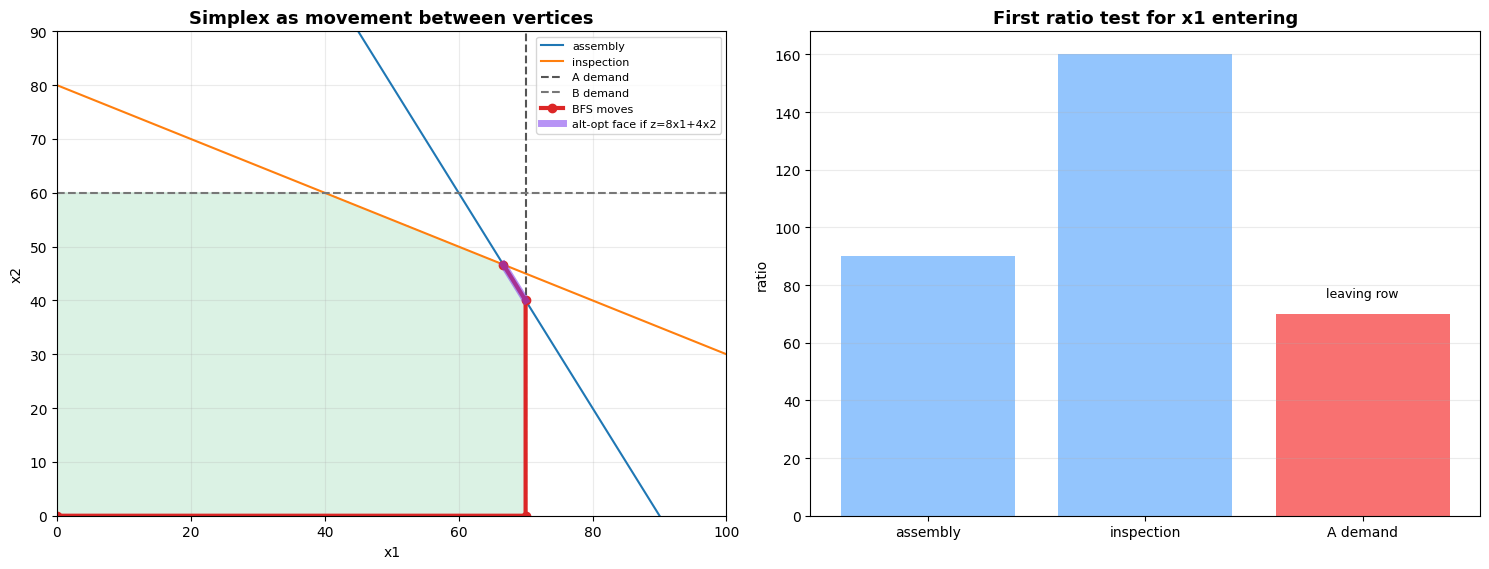

In [2]:
# P0004 Board 1: Smart logistics LP movement and alternate-optimal segment
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
x = np.linspace(0, 100, 500)
y = np.linspace(0, 90, 500)
X, Y = np.meshgrid(x, y)
F = (2*X+Y<=180) & (X+2*Y<=160) & (X<=70) & (Y<=60) & (X>=0) & (Y>=0)
ax.contourf(X, Y, F.astype(float), levels=[0.5,1.5], colors=["#d9f2e3"], alpha=0.95)
ax.plot(x, 180-2*x, label="assembly")
ax.plot(x, (160-x)/2, label="inspection")
ax.axvline(70, color="#555", ls="--", label="A demand")
ax.axhline(60, color="#777", ls="--", label="B demand")
path = np.array([[0,0],[70,0],[70,40],[200/3,140/3]])
ax.plot(path[:,0], path[:,1], "o-", color="#dc2626", lw=3, label="BFS moves")
ax.plot([70, 200/3], [40, 140/3], color="#7c3aed", lw=5, alpha=0.55, label="alt-opt face if z=8x1+4x2")
ax.set_xlim(0,100); ax.set_ylim(0,90)
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("Simplex as movement between vertices")
ax.grid(alpha=0.25); ax.legend(fontsize=8)

ax = axes[1]
rows = ["assembly", "inspection", "A demand", "B demand"]
ratios = [90,160,70,np.nan]
ax.bar(rows[:3], ratios[:3], color=["#93c5fd","#93c5fd","#f87171"])
ax.text(2, 76, "leaving row", ha="center", fontsize=9)
ax.set_title("First ratio test for x1 entering")
ax.set_ylabel("ratio")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


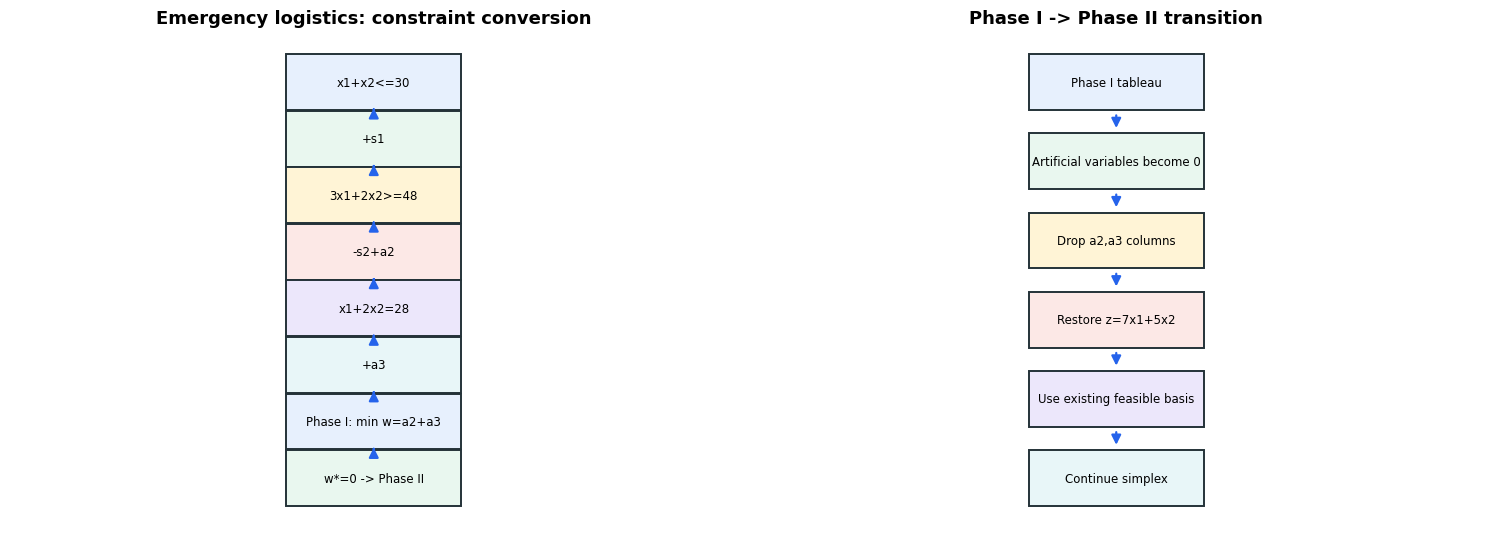

In [3]:
# P0004 Board 2: Emergency logistics two-phase mechanism
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

draw_flow(
    axes[0],
    [
        ["x1+x2<=30"],
        ["+s1"],
        ["3x1+2x2>=48"],
        ["-s2+a2"],
        ["x1+2x2=28"],
        ["+a3"],
        ["Phase I: min w=a2+a3"],
        ["w*=0 -> Phase II"]
    ],
    "Emergency logistics: constraint conversion"
)

draw_flow(
    axes[1],
    [
        ["Phase I tableau"],
        ["Artificial variables become 0"],
        ["Drop a2,a3 columns"],
        ["Restore z=7x1+5x2"],
        ["Use existing feasible basis"],
        ["Continue simplex"]
    ],
    "Phase I -> Phase II transition"
)
plt.tight_layout()
plt.show()


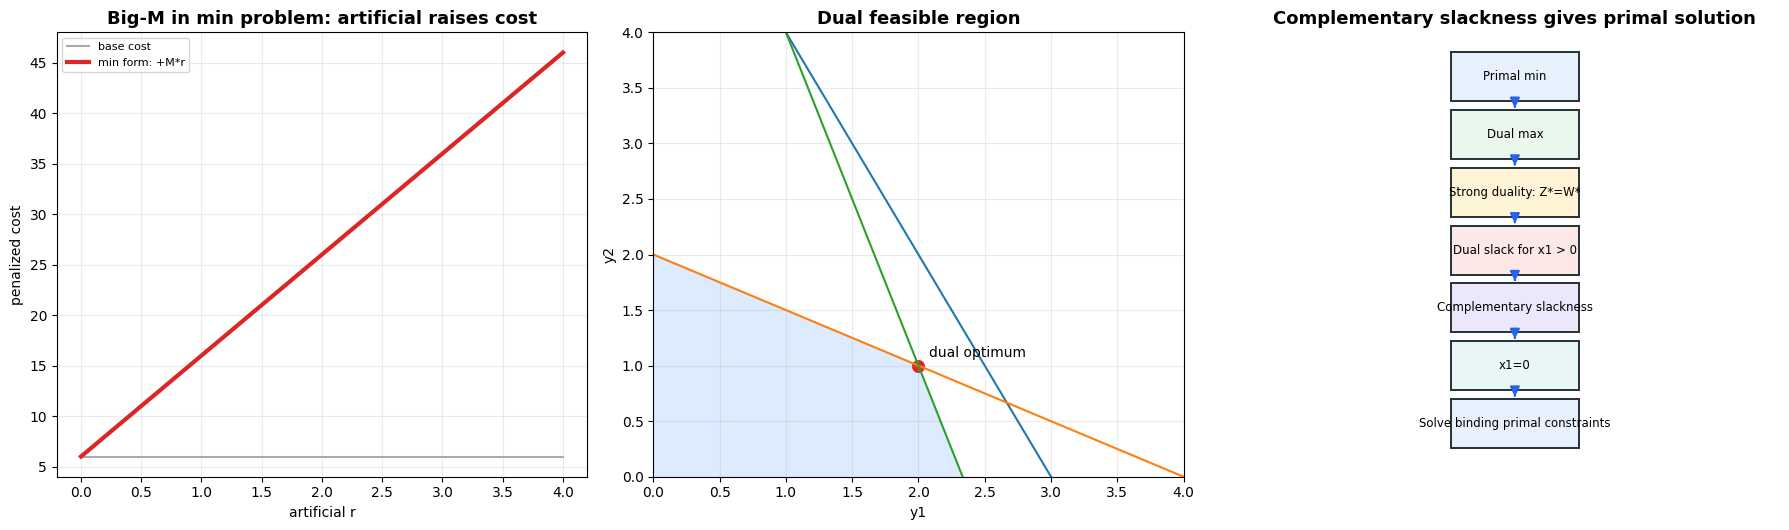

In [4]:
# P0004 Board 3: Big-M and duality for eco-parts procurement
fig, axes = plt.subplots(1, 3, figsize=(18, 5.4))

ax = axes[0]
r = np.linspace(0, 4, 100)
ax.plot(r, 6 + r*0, color="#aaa", label="base cost")
ax.plot(r, 6 + 10*r, color="#dc2626", lw=3, label="min form: +M*r")
ax.set_title("Big-M in min problem: artificial raises cost")
ax.set_xlabel("artificial r"); ax.set_ylabel("penalized cost")
ax.grid(alpha=0.25); ax.legend(fontsize=8)

ax = axes[1]
y1 = np.linspace(0, 4, 500)
c1 = 6 - 2*y1
c2 = (4-y1)/2
c3 = 7 - 3*y1
Y1, Y2 = np.meshgrid(np.linspace(0,4,450), np.linspace(0,4,450))
F = (2*Y1+Y2<=6) & (Y1+2*Y2<=4) & (3*Y1+Y2<=7) & (Y1>=0) & (Y2>=0)
ax.contourf(Y1, Y2, F.astype(float), levels=[0.5,1.5], colors=["#dbeafe"], alpha=0.95)
ax.plot(y1, c1); ax.plot(y1, c2); ax.plot(y1, c3)
ax.scatter([2],[1], c="#dc2626", s=70)
ax.text(2.08,1.08,"dual optimum")
ax.set_xlim(0,4); ax.set_ylim(0,4)
ax.set_xlabel("y1"); ax.set_ylabel("y2")
ax.set_title("Dual feasible region")
ax.grid(alpha=0.25)

draw_flow(
    axes[2],
    [
        ["Primal min"],
        ["Dual max"],
        ["Strong duality: Z*=W*"],
        ["Dual slack for x1 > 0"],
        ["Complementary slackness"],
        ["x1=0"],
        ["Solve binding primal constraints"]
    ],
    "Complementary slackness gives primal solution"
)
plt.tight_layout()
plt.show()


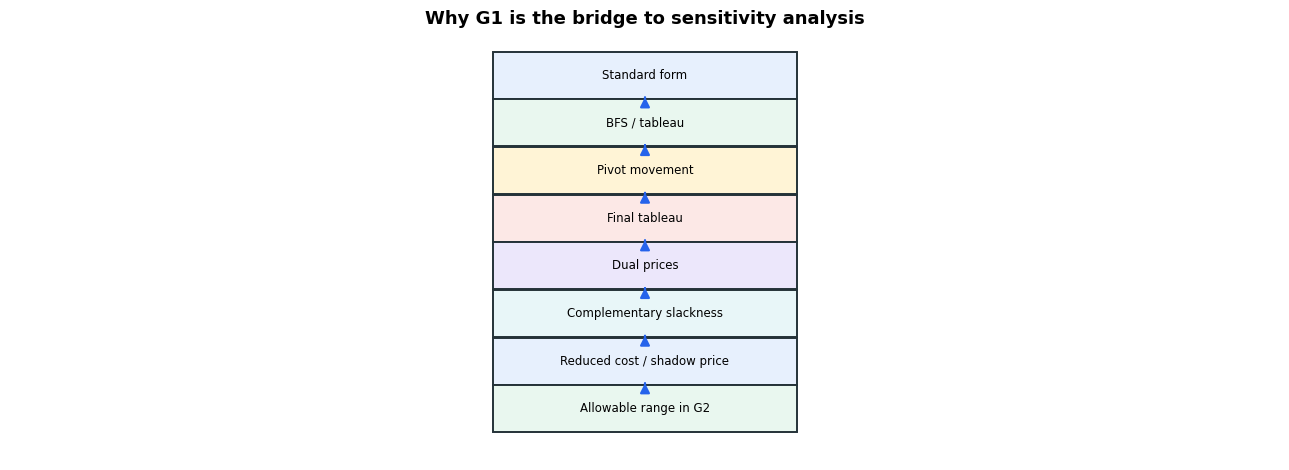

In [5]:
# P0004 Board 4: G1 -> G2 bridge
fig, ax = plt.subplots(figsize=(13, 4.8))
draw_flow(
    ax,
    [
        ["Standard form"],
        ["BFS / tableau"],
        ["Pivot movement"],
        ["Final tableau"],
        ["Dual prices"],
        ["Complementary slackness"],
        ["Reduced cost / shadow price"],
        ["Allowable range in G2"]
    ],
    "Why G1 is the bridge to sensitivity analysis"
)
plt.tight_layout()
plt.show()


## 3. 채점 기준

| 평가 항목 | 배점 |
| --- | ---: |
| 표준형, BFS, tableau 구성 | 15 |
| entering/leaving/ratio/pivot 판정 | 15 |
| 특수 종료 신호: 최적/복수최적/비유계/infeasible | 15 |
| slack/surplus/artificial variable 및 two-phase 해석 | 20 |
| Big-M formulation과 부호 판정 | 15 |
| duality, weak/strong, complementary slackness | 15 |
| Solver mapping, source anchor, node_id | 5 |

부분점 기준:

- 계산값이 일부 틀려도 판정 논리와 부호 해석이 맞으면 해당 항목의 절반 이상을 줄 수 있다.
- ratio test에서 제외 행을 명시하지 않으면 pivot 판정 항목에서 감점한다.
- artificial variable이 최종적으로 0이어야 한다는 설명이 없으면 two-phase/Big-M 항목에서 크게 감점한다.
- dual objective와 dual constraints 중 하나라도 대응 방향이 틀리면 duality 항목에서 감점한다.


## 4. 오답튜터 기준표

| 오류 | 피드백 기준 |
| --- | --- |
| ratio test에서 음수 계수 포함 | 양수 entering column 계수만 후보라고 교정한다. |
| pivot을 단순 계산으로만 이해 | basis 교체와 꼭짓점 이동 의미를 설명한다. |
| reduced cost 0 오해 | 복수 최적해 가능성과 대안 entering 후보로 설명한다. |
| unbounded/infeasible 혼동 | feasible 해 존재 여부와 objective bound를 분리한다. |
| surplus 부호 오류 | `>=` 제약의 초과량은 좌변에서 빼야 한다고 설명한다. |
| artificial 실제 변수화 | 원문제에 없는 임시 변수이며 최종 0이어야 한다고 설명한다. |
| w=0과 z=0 혼동 | Phase I objective와 원 목적함수를 분리한다. |
| Big-M 부호 오류 | artificial이 커질수록 objective가 나빠져야 한다고 설명한다. |
| primal-dual mapping 오류 | primal 제약 수와 dual 변수 수를 먼저 세게 한다. |
| complementary slackness 오류 | slack이 양수이면 대응 dual variable은 0이어야 한다고 설명한다. |
| reduced cost/shadow price 혼동 | 변수 질문과 RHS 질문을 분리한다. |


## 5. 다음 학습 연결

후속 Phase는 G2 sensitivity analysis다.

“G1에서 final tableau, duality, complementary slackness를 이해하면 G2의 sensitivity report에서 reduced cost, shadow price, allowable increase/decrease를 해석할 수 있다. 즉 P0004는 simplex 계산에서 sensitivity 해석으로 넘어가는 마지막 다리다.”
